# Cross-functional Bubble Chart

**X-axis** — Jensen-Shannon Divergence of topic-cluster distribution vs Tagesschau  
**Y-axis** — Delegitimisation rate (framing hits / non-IRRELEVANT hits per outlet)  
**Colour** — Mean anger score (sigmoid, full-text emotion model)  
Each bubble = one alternative outlet (Tagesschau is the reference origin).

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial.distance import jensenshannon

ROOT = Path("/Users/gretawette/Documents/Thesis")

topics_path   = ROOT / "02_TopicModeling/outputs/03_new_topic_assignments.csv"
framing_path  = ROOT / "03_Framing/outputs/media_framing_final_run_5_4mini_classifications.csv"
emotion_path  = ROOT / "04_SentimentAnalysis/outputs/emotion_fulltext_resultsv2.csv"


In [10]:
# ── Topic-cluster distributions & JSD vs Tagesschau ─────────────────────────
topics = pd.read_csv(topics_path)
topics["Manual Cluster Label"] = topics["Manual Cluster Label"].str.rstrip("#").str.strip()

# Normalise source names to match framing & emotion datasets
topics["source"] = topics["source"].replace({
    "RT":             "RT_de",
    "Tichys Einblick": "Tichys_Einblick",
})

# Article-level: one row per article, one cluster label
# Use article-level counts (row_id is unique per article)
art = topics.drop_duplicates("row_id")[["source", "Manual Cluster Label"]].dropna()

# Topic distribution per outlet (proportions over clusters)
dist = (
    art.groupby(["source", "Manual Cluster Label"])
    .size()
    .unstack(fill_value=0)
)
dist_norm = dist.div(dist.sum(axis=1), axis=0)   # row-normalised to proportions

# JSD vs Tagesschau (base-2, so max = 1)
tg_dist = dist_norm.loc["Tagesschau"].values if "Tagesschau" in dist_norm.index else None
if tg_dist is None:
    raise ValueError("Tagesschau not found in topic assignments.")

jsd_scores = {}
for outlet in dist_norm.index:
    if outlet == "Tagesschau":
        continue
    jsd_scores[outlet] = float(jensenshannon(dist_norm.loc[outlet].values, tg_dist, base=2))

jsd_series = pd.Series(jsd_scores, name="jsd")
print("JSD scores:\n", jsd_series.sort_values(ascending=False))


JSD scores:
 Antispiegel          0.566669
Deutschlandkurier    0.382088
Compact              0.371468
RT_de                0.345574
Nius                 0.344791
Tichys_Einblick      0.295440
Name: jsd, dtype: float64


In [11]:
# ── Delegitimisation rate per outlet ─────────────────────────────────────────
framing = pd.read_csv(framing_path)
framing = framing[framing["category"] != "IRRELEVANT"]   # drop irrelevant

deleg = (
    framing.groupby("source")
    .apply(lambda g: (g["category"] != "NEUTRAL").sum() / len(g))
    .rename("deleg_rate")
)
print("Delegitimisation rates:\n", deleg.sort_values(ascending=False))


Delegitimisation rates:
 source
Antispiegel          0.567251
Tichys_Einblick      0.504982
Nius                 0.391061
Compact              0.346491
Deutschlandkurier    0.325397
RT_de                0.187879
Tagesschau           0.007164
Name: deleg_rate, dtype: float64


In [12]:
# ── Mean anger per outlet (full-text emotion model) ──────────────────────────
emotions = pd.read_csv(emotion_path)
emotions["emotion_anger"] = pd.to_numeric(emotions["emotion_anger"], errors="coerce")

anger_mean = (
    emotions.groupby("source")["emotion_anger"]
    .mean()
    .rename("mean_anger")
)
print("Mean anger:\n", anger_mean.sort_values(ascending=False))


Mean anger:
 source
Tichys_Einblick      0.843428
Compact              0.782459
Antispiegel          0.752715
Deutschlandkurier    0.742301
Nius                 0.735449
Tagesschau           0.665632
RT_de                0.664739
Name: mean_anger, dtype: float64


                        jsd  deleg_rate  mean_anger
Antispiegel        0.566669    0.567251    0.752715
Tichys_Einblick    0.295440    0.504982    0.843428
Nius               0.344791    0.391061    0.735449
Compact            0.371468    0.346491    0.782459
Deutschlandkurier  0.382088    0.325397    0.742301
RT_de              0.345574    0.187879    0.664739


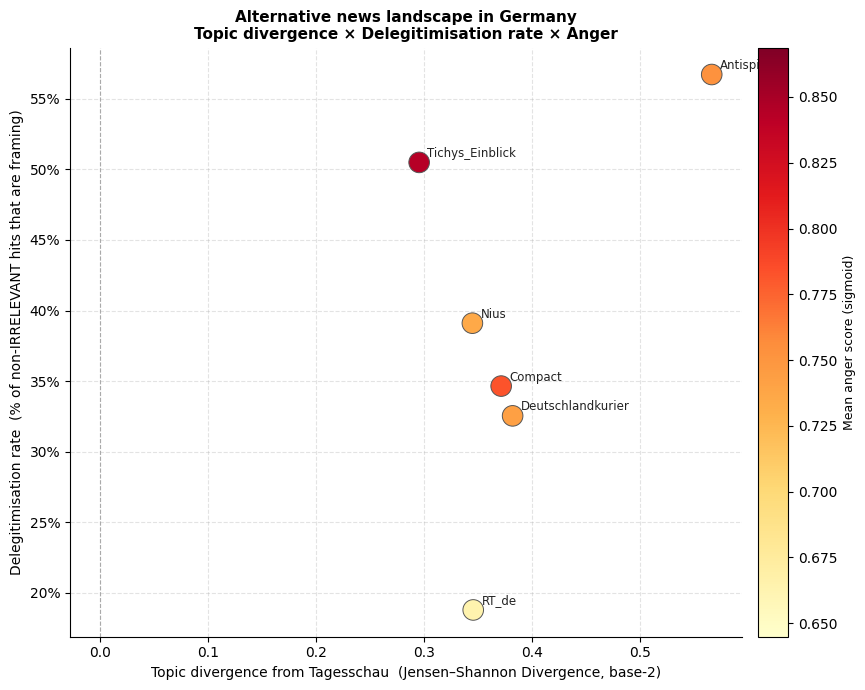

In [17]:
# ── Merge the three metrics ───────────────────────────────────────────────────
df_plot = (
    pd.DataFrame(jsd_series)
    .join(deleg, how="inner")
    .join(anger_mean, how="inner")
    .dropna()
)
df_plot = df_plot[df_plot.index != "Tagesschau"]
print(df_plot.sort_values("deleg_rate", ascending=False))

# ── Bubble chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

# Colour map: light yellow → deep red (anger intensity)
cmap  = plt.cm.YlOrRd
norm  = mcolors.Normalize(
    vmin=df_plot["mean_anger"].min() * 0.97,
    vmax=df_plot["mean_anger"].max() * 1.03,
)
colors = cmap(norm(df_plot["mean_anger"].values))

sc = ax.scatter(
    df_plot["jsd"],
    df_plot["deleg_rate"] * 100,
    c=df_plot["mean_anger"],
    cmap=cmap,
    norm=norm,
    s=220,
    edgecolors="#555555",
    linewidths=0.7,
    zorder=3,
)

# Outlet labels (offset to avoid overlap)
for outlet, row in df_plot.iterrows():
    ax.annotate(
        outlet,
        xy=(row["jsd"], row["deleg_rate"] * 100),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=8.5,
        color="#222222",
    )

# Tagesschau reference cross-hair
ax.axvline(0, color="#aaaaaa", linewidth=0.8, linestyle="--", zorder=1)

# Colour bar
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Mean anger score (sigmoid)", fontsize=9)

ax.set_xlabel(
    "Topic divergence from Tagesschau  (Jensen–Shannon Divergence, base-2)",
    fontsize=10,
)
ax.set_ylabel(
    "Delegitimisation rate  (% of non-IRRELEVANT hits that are framing)",
    fontsize=10,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_title( "Alternative news landscape in Germany\n"
    "Topic divergence × Delegitimisation rate × Anger",
    fontsize=11, fontweight="bold",
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(ROOT / "05_Crossfunctional_Analysis/figures/bubble_divergence_deleg_anger.png",
            dpi=150, bbox_inches="tight")
plt.show()
